  species     island  culmen_length_mm  culmen_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen              39.1             18.7              181.0   
1  Adelie  Torgersen              39.5             17.4              186.0   
2  Adelie  Torgersen              40.3             18.0              195.0   
3  Adelie  Torgersen               NaN              NaN                NaN   
4  Adelie  Torgersen              36.7             19.3              193.0   

   body_mass_g     sex  
0       3750.0    MALE  
1       3800.0  FEMALE  
2       3250.0  FEMALE  
3          NaN     NaN  
4       3450.0  FEMALE  


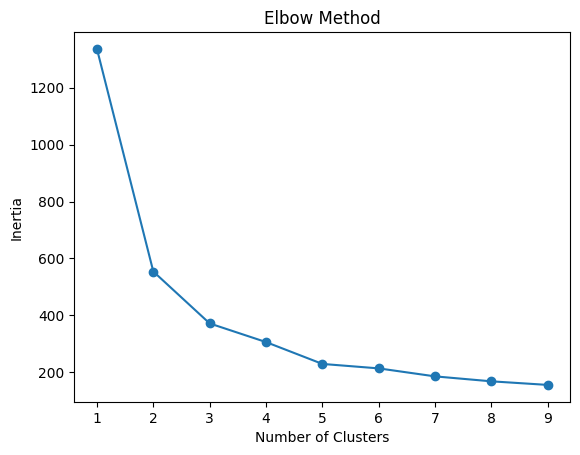


K-Means Cluster Counts
KMeans_Cluster
2    129
1    120
0     85
Name: count, dtype: int64

Hierarchical Cluster Counts
Hierarchical_Cluster
0    157
1    120
2     57
Name: count, dtype: int64


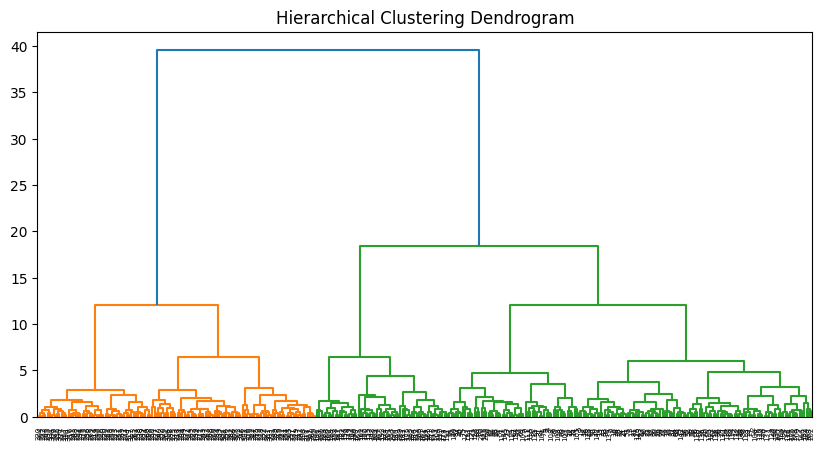

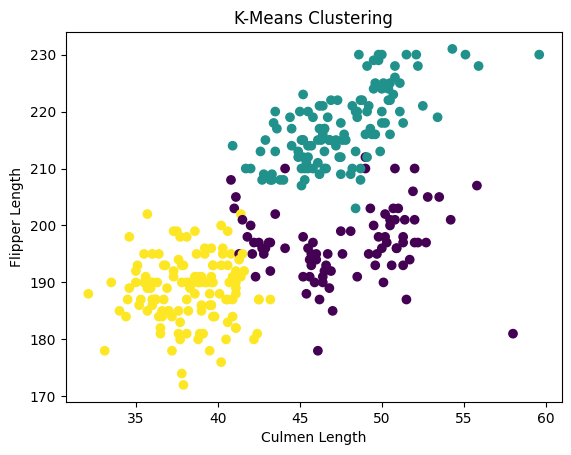


Silhouette Score: 0.4467665403072799


In [1]:
# K-MEANS AND HIERARCHICAL CLUSTERING

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage


# -----------------------------
# Load Dataset
# -----------------------------

df = pd.read_csv("penguins_size.csv")

print(df.head())


# -----------------------------
# Data Preprocessing
# -----------------------------

df = df.dropna()

label = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = label.fit_transform(df[column])


# -----------------------------
# Feature Selection
# -----------------------------

X = df[['culmen_length_mm','culmen_depth_mm','flipper_length_mm','body_mass_g']]


# -----------------------------
# Feature Scaling
# -----------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


# -----------------------------
# Hyperparameter Tuning (Elbow Method)
# -----------------------------

inertia = []

K = range(1,10)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()


# -----------------------------
# Apply K-Means
# -----------------------------

kmeans = KMeans(n_clusters=3, random_state=42)

clusters = kmeans.fit_predict(X_scaled)

df['KMeans_Cluster'] = clusters

print("\nK-Means Cluster Counts")
print(df['KMeans_Cluster'].value_counts())


# -----------------------------
# Hierarchical Clustering
# -----------------------------

hierarchical = AgglomerativeClustering(n_clusters=3)

h_clusters = hierarchical.fit_predict(X_scaled)

df['Hierarchical_Cluster'] = h_clusters

print("\nHierarchical Cluster Counts")
print(df['Hierarchical_Cluster'].value_counts())


# -----------------------------
# Dendrogram
# -----------------------------

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,5))

dendrogram(linked)

plt.title("Hierarchical Clustering Dendrogram")

plt.show()


# -----------------------------
# Cluster Visualization
# -----------------------------

plt.scatter(df['culmen_length_mm'], df['flipper_length_mm'], c=clusters)

plt.xlabel("Culmen Length")

plt.ylabel("Flipper Length")

plt.title("K-Means Clustering")

plt.show()


# -----------------------------
# Silhouette Score
# -----------------------------

score = silhouette_score(X_scaled, clusters)

print("\nSilhouette Score:", score)

Clusters: 2 Silhouette Score: 0.5305869818197954
Clusters: 3 Silhouette Score: 0.4467665403072799
Clusters: 4 Silhouette Score: 0.42116935732515565
Clusters: 5 Silhouette Score: 0.3744608103908937
Clusters: 6 Silhouette Score: 0.31789187380420686
Clusters: 7 Silhouette Score: 0.31850448991333213
Clusters: 8 Silhouette Score: 0.2797620272352486
Clusters: 9 Silhouette Score: 0.28803594433243007


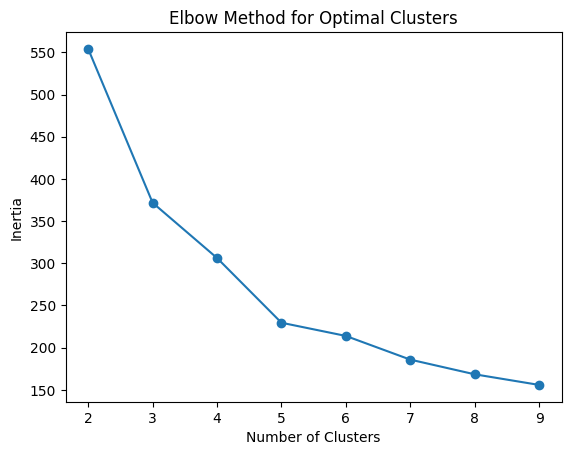

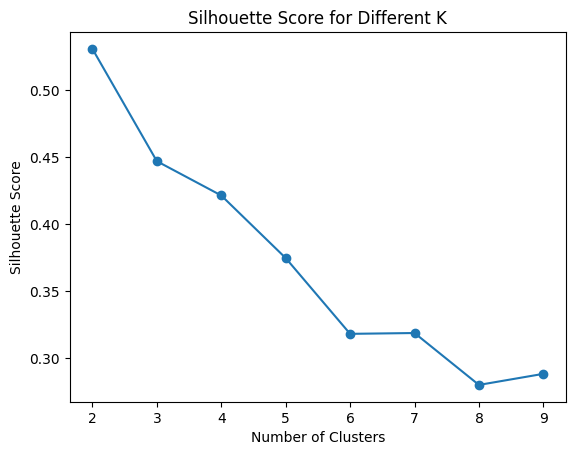

In [2]:
# -----------------------------------
# Hyperparameter Tuning for K-Means
# -----------------------------------

from sklearn.metrics import silhouette_score

inertia = []
silhouette_scores = []

K = range(2,10)

for k in K:

    kmeans = KMeans(n_clusters=k, random_state=42)

    clusters = kmeans.fit_predict(X_scaled)

    inertia.append(kmeans.inertia_)

    score = silhouette_score(X_scaled, clusters)

    silhouette_scores.append(score)

    print("Clusters:", k, "Silhouette Score:", score)


# -----------------------------------
# Plot Elbow Curve
# -----------------------------------

import matplotlib.pyplot as plt

plt.plot(K, inertia, marker='o')

plt.title("Elbow Method for Optimal Clusters")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.show()


# -----------------------------------
# Plot Silhouette Scores
# -----------------------------------

plt.plot(K, silhouette_scores, marker='o')

plt.title("Silhouette Score for Different K")

plt.xlabel("Number of Clusters")

plt.ylabel("Silhouette Score")

plt.show()

In [3]:
from sklearn.cluster import AgglomerativeClustering

linkage_methods = ['ward','complete','average','single']

for method in linkage_methods:

    model = AgglomerativeClustering(n_clusters=3, linkage=method)

    clusters = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, clusters)

    print("Linkage:", method, "Silhouette Score:", score)

Linkage: ward Silhouette Score: 0.4527301285721841
Linkage: complete Silhouette Score: 0.45303666313119506
Linkage: average Silhouette Score: 0.45541811986979586
Linkage: single Silhouette Score: 0.46727170841783555
